First 5 Rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Model Performance
------------------------------
MAE : 0.903
MSE : 1.443
RMSE: 1.201
R² Score: 0.953


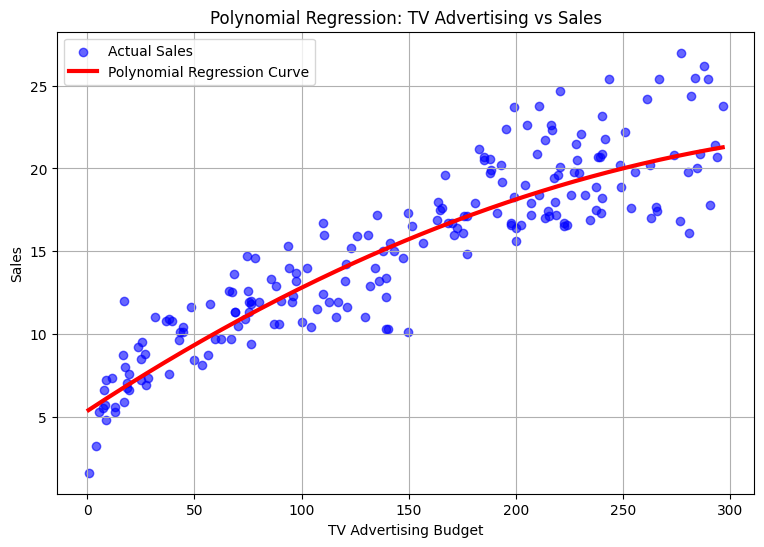


Predicted Sales for:
    TV  Radio  Newspaper
0  150     25         30

Estimated Sales: 15.91


In [ ]:
# Polynomial Regression on Advertising Dataset

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("advertising[1].csv")

# Display first few rows
print("First 5 Rows:")
print(df.head())

# Features and Target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Polynomial Regression Pipeline
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Performance")
print("-" * 30)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")

# -------------------------------
# Visualization (TV vs Sales)
# -------------------------------

# Generate smooth TV values
tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 300)

# Keep Radio and Newspaper fixed at their average values
radio_mean = df['Radio'].mean()
news_mean = df['Newspaper'].mean()

X_curve = pd.DataFrame({
    'TV': tv_range,
    'Radio': radio_mean,
    'Newspaper': news_mean
})

sales_curve = model.predict(X_curve)

plt.figure(figsize=(9,6))
plt.scatter(df['TV'], df['Sales'], color='blue', alpha=0.6, label='Actual Sales')
plt.plot(tv_range, sales_curve, color='red', linewidth=3,
         label='Polynomial Regression Curve')

plt.title("Polynomial Regression: TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Example Prediction
# -------------------------------

new_budget = pd.DataFrame({
    'TV':[150],
    'Radio':[25],
    'Newspaper':[30]
})

prediction = model.predict(new_budget)

print("\nPredicted Sales for:")
print(new_budget)
print(f"\nEstimated Sales: {prediction[0]:.2f}")